In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

RACINE = Path.cwd()
while not (RACINE / "src").exists() and RACINE != RACINE.parent:
    RACINE = RACINE.parent

f = pd.read_parquet(RACINE / "data" / "processed" / "ventes_features.parquet")
variables = [c for c in f.columns if c.startswith(("dist_", "nb_"))]
f[variables].describe().T.round(0)

,count,mean,std,min,25%,50%,75%,max
nb_dependances,23703.0,1.0,1.0,0.0,0.0,1.0,1.0,7.0
dist_centre,23703.0,2231.0,1298.0,35.0,1218.0,2035.0,3120.0,6608.0
dist_tram,23703.0,337.0,237.0,12.0,164.0,273.0,451.0,1507.0
dist_ecole,23703.0,264.0,181.0,12.0,135.0,218.0,340.0,1509.0
nb_ecole_500m,23703.0,5.0,4.0,0.0,2.0,4.0,7.0,20.0
dist_parc,23703.0,229.0,141.0,15.0,128.0,200.0,291.0,1093.0
dist_commerce,23703.0,132.0,107.0,1.0,50.0,106.0,189.0,916.0
nb_commerce_500m,23703.0,97.0,184.0,0.0,13.0,27.0,62.0,922.0
dist_restaurant,23703.0,236.0,198.0,1.0,82.0,196.0,341.0,1389.0
nb_restaurant_500m,23703.0,41.0,87.0,0.0,2.0,6.0,27.0,420.0


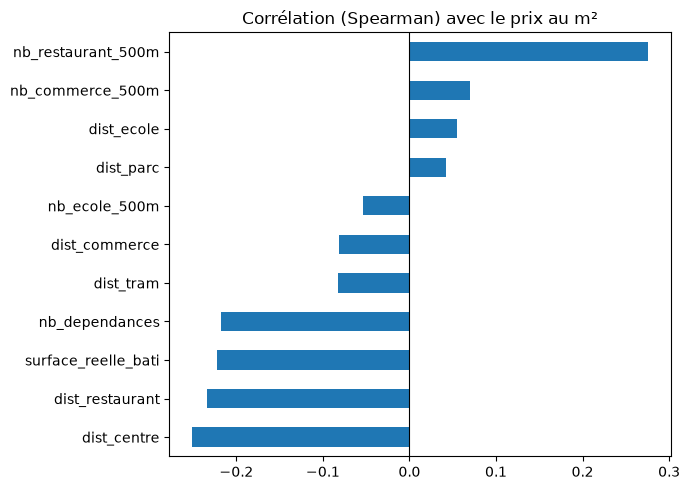

In [2]:
correlations = f[variables + ["surface_reelle_bati", "prix_m2"]].corr(method="spearman")["prix_m2"]
correlations.drop("prix_m2").sort_values().plot.barh(figsize=(7, 5))
plt.title("Corrélation (Spearman) avec le prix au m²")
plt.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

In [3]:
appartements = f[f["type_local"] == "Appartement"].copy()
tranches = [0, 200, 400, 600, 1000, 2000, 10_000]
appartements["tranche_tram"] = pd.cut(appartements["dist_tram"], tranches)
appartements.groupby("tranche_tram", observed=True)["prix_m2"].agg(["median", "count"]).round(0)

,median,count
tranche_tram,,
"(0, 200]",3490.0,7700
"(200, 400]",3303.0,7721
"(400, 600]",3120.0,3350
"(600, 1000]",3171.0,2117
"(1000, 2000]",3066.0,425


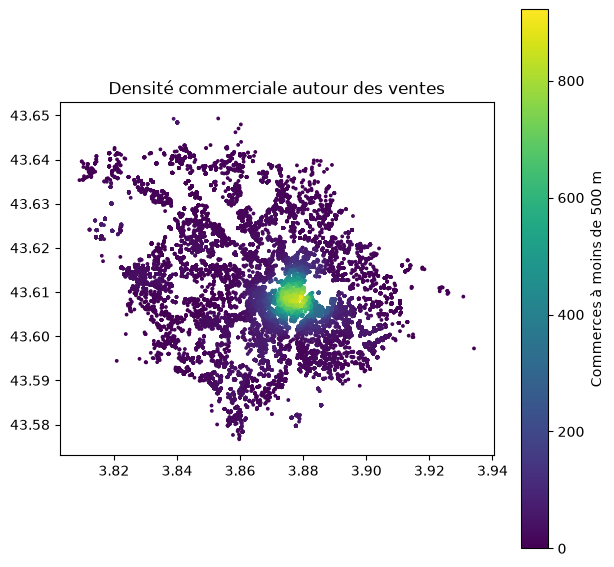

In [4]:
fig, ax = plt.subplots(figsize=(7, 7))
sc = ax.scatter(f["longitude"], f["latitude"], c=f["nb_commerce_500m"], s=3, cmap="viridis")
plt.colorbar(sc, label="Commerces à moins de 500 m")
ax.set_title("Densité commerciale autour des ventes")
ax.set_aspect(1.4)
plt.show()